# Linear regression for Diabetes dataset - lesson 1


In [1]:
import matplotlib.pyplot as plt
import numpy as np 
#from sklearn import datasets, linear_model, model_selection
import pandas as pd
from datetime import datetime

In [2]:
data = pd.read_csv('US-pumpkins.csv')
data.columns

Index(['City Name', 'Type', 'Package', 'Variety', 'Sub Variety', 'Grade',
       'Date', 'Low Price', 'High Price', 'Mostly Low', 'Mostly High',
       'Origin', 'Origin District', 'Item Size', 'Color', 'Environment',
       'Unit of Sale', 'Quality', 'Condition', 'Appearance', 'Storage', 'Crop',
       'Repack', 'Trans Mode', 'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

In [3]:
data = data[data['Package'].str.contains('bushel', case=True, regex=True)]
month = pd.DatetimeIndex(data['Date']).month
day_of_year = pd.to_datetime(data['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)
price = (data['High Price'] + data['Low Price'])/2
new_data = pd.DataFrame({'Month': month, 'DayOfYear': day_of_year, 'Price': price,'Package': data['Package'],'City Name': data['City Name'], 'Variety':data['Variety'], 'Low Price': data['Low Price'], 'High Price': data['High Price']})
new_data.loc[new_data['Package'].str.contains('1 1/9'), 'Price'] = price/1.1
new_data.loc[new_data['Package'].str.contains('1/2'), 'Price'] = price*2
new_data.head()

C:\Users\PC\AppData\Local\Temp\ipykernel_17908\3779348516.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(data['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)


,Month,DayOfYear,Price,Package,City Name,Variety,Low Price,High Price
70,9,267,13.636364,1 1/9 bushel cartons,BALTIMORE,PIE TYPE,15.0,15.0
71,9,267,16.363636,1 1/9 bushel cartons,BALTIMORE,PIE TYPE,18.0,18.0
72,10,274,16.363636,1 1/9 bushel cartons,BALTIMORE,PIE TYPE,18.0,18.0
73,10,274,15.454545,1 1/9 bushel cartons,BALTIMORE,PIE TYPE,17.0,17.0
74,10,281,13.636364,1 1/9 bushel cartons,BALTIMORE,PIE TYPE,15.0,15.0


<Axes: xlabel='Month', ylabel='Price'>

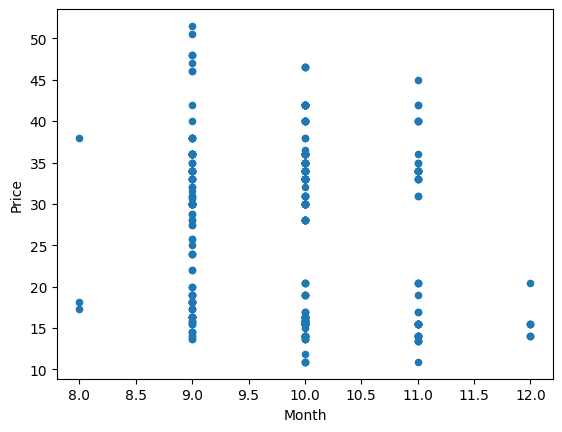

In [4]:
new_data.plot.scatter('Month', 'Price')

<Axes: xlabel='DayOfYear', ylabel='Price'>

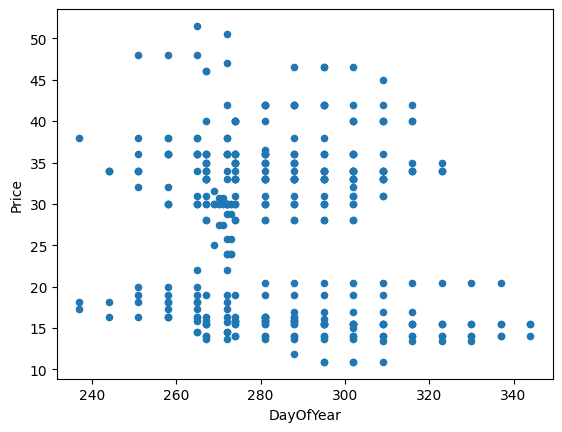

In [5]:
new_data.plot.scatter('DayOfYear', 'Price')

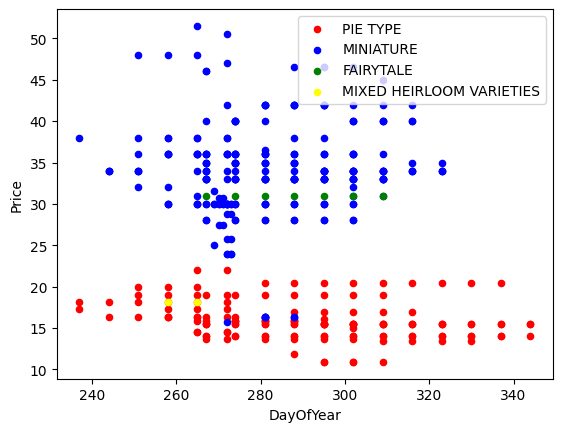

In [6]:
ax = None
colors = ['red', 'blue', 'green', 'yellow']
for i, var in enumerate(new_data['Variety'].unique()):
    ax = new_data[new_data['Variety'] == var].plot.scatter('DayOfYear', 'Price', c=colors[i], label=var, ax=ax)

<Axes: xlabel='Variety'>

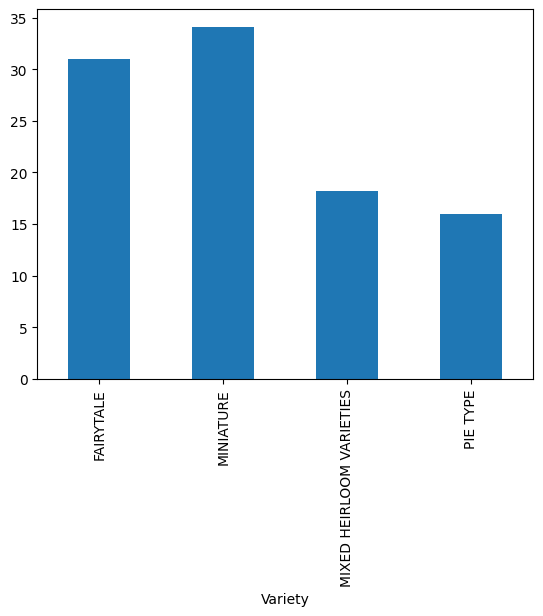

In [7]:
new_data.groupby('Variety')['Price'].mean().plot(kind='bar')

In [8]:
pie_data = new_data[new_data['Variety']=='PIE TYPE']
print(pie_data['DayOfYear'].corr(pie_data['Price']))

-0.2669192282197318


## Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

R^2:  0.10220539781539772
RMSE:  2.7688573289058405


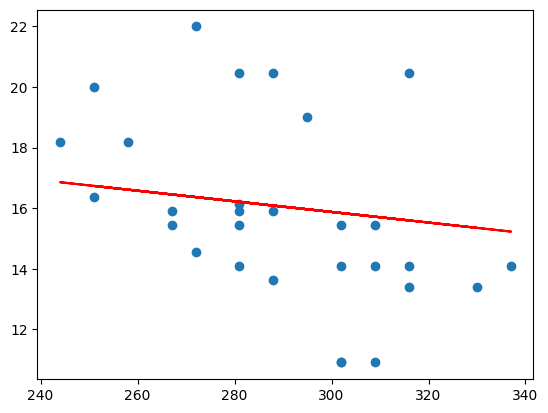

In [10]:
X = pie_data['DayOfYear'].to_numpy().reshape(-1,1)
y = pie_data['Price']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R^2: ",r2_score(y_test, y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test, y_pred)))
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.show()

## Polynomial Regression

root Mean squear error:  2.730043608445106
Model determination:  0.12719946902474621


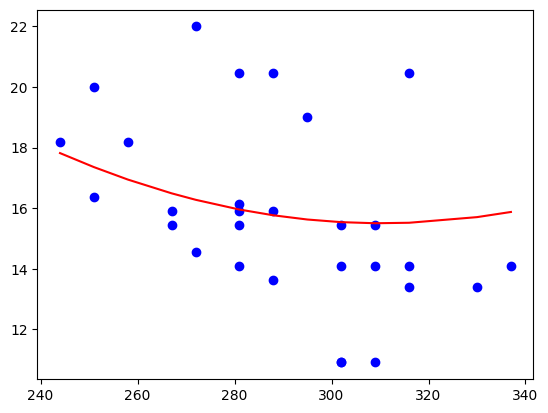

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)
y_pred_poly = pipeline.predict(X_test)

mse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
print("root Mean squear error: ", mse)
score = pipeline.score(X_test, y_test)
print("Model determination: ", score)
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(sorted(X_test), pipeline.predict(sorted(X_test)), color='red')

### Encoding varieties

In [12]:
pd.get_dummies(new_data['Variety'])

,FAIRYTALE,MINIATURE,MIXED HEIRLOOM VARIETIES,PIE TYPE
70,False,False,False,True
71,False,False,False,True
72,False,False,False,True
73,False,False,False,True
74,False,False,False,True
...,...,...,...,...
1738,False,True,False,False
1739,False,True,False,False
1740,False,True,False,False
1741,False,True,False,False


In [13]:
X = pd.get_dummies(new_data['Variety'])
y = new_data['Price']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Mean error: {mse:3.3}, ({mse/np.mean(y_pred)*100:3.3}%)")
print("R^2: ",model.score(X_train, y_train))


Mean error: 5.24, (19.7%)
R^2:  0.774085281105197


In [14]:
X = pd.get_dummies(new_data['Variety']) \
.join(new_data['Month']) \
.join(pd.get_dummies(new_data['City Name'])) \
.join(pd.get_dummies(new_data['Package']))
y = new_data['Price']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
mse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Mean error: {mse:3.3}, ({mse/np.mean(y_pred)*100:3.3}%)")
print("R^2(Modelm determination): ",pipeline.score(X_train, y_train))

Mean error: 2.23, (8.28%)
R^2(Modelm determination):  0.9653029999448537
